# Waypoint Constraints

This example constrains a cruise trajectory from Amsterdam Schiphol (`EHAM`) to Frankfurt (`EDDF`) through named fixes from OpenAP's packaged navigation database. The fixes lie close to the route corridor, so the optimizer can use a 100 m waypoint tolerance.

In [1]:
import warnings

import matplotlib.pyplot as plt
import openap
from cartopy import crs as ccrs
from cartopy.feature import BORDERS, LAND, OCEAN

import opentop as top

warnings.filterwarnings("ignore")

In [2]:
fix_names = ("RONAD", "ABAXA", "ETARU")

waypoints = []
for fix_name in fix_names:
    lat, lon, _ = openap.nav.fix(fix_name)
    waypoints.append((float(lat), float(lon)))

list(zip(fix_names, waypoints))

[('RONAD', (51.289122, 6.552869)),
 ('ABAXA', (50.764667, 7.385833)),
 ('ETARU', (50.285553, 8.112222))]

In [3]:
optimizer = top.Cruise("A320", "EHAM", "EDDF", 0.85)

flight = optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=100,
)

fuel_burn = flight.mass.iloc[0] - flight.mass.iloc[-1]
elapsed_time = flight.ts.iloc[-1] / 60

print("Route: EHAM -> " + " -> ".join(fix_names) + " -> EDDF")
print(f"Fuel burn: {fuel_burn:.1f} kg")
print(f"Elapsed time: {elapsed_time:.1f} min")

Route: EHAM -> RONAD -> ABAXA -> ETARU -> EDDF
Fuel burn: 1209.2 kg
Elapsed time: 26.2 min


In [4]:
for fix_name, waypoint in zip(fix_names, waypoints):
    distances = [
        openap.aero.distance(lat, lon, waypoint[0], waypoint[1])
        for lat, lon in zip(flight.latitude, flight.longitude)
    ]
    print(f"{fix_name}: closest trajectory point {min(distances) / 1000:.1f} km")

RONAD: closest trajectory point 0.1 km
ABAXA: closest trajectory point 0.1 km
ETARU: closest trajectory point 0.1 km


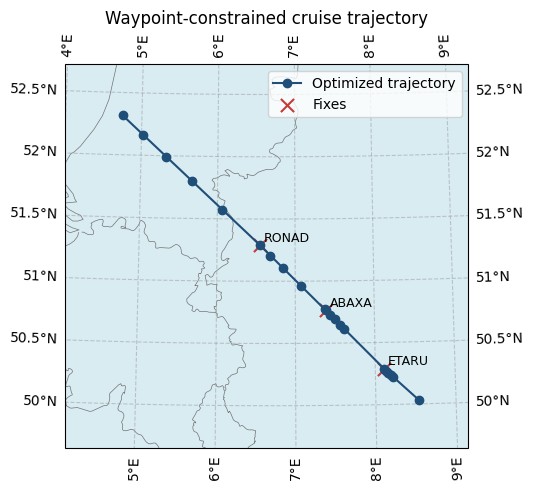

In [5]:
projection = ccrs.TransverseMercator(central_longitude=6.7, central_latitude=51.2)
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={"projection": projection})

lon_min = min(flight.longitude.min(), min(lon for _, lon in waypoints)) - 0.6
lon_max = max(flight.longitude.max(), max(lon for _, lon in waypoints)) + 0.6
lat_min = min(flight.latitude.min(), min(lat for lat, _ in waypoints)) - 0.4
lat_max = max(flight.latitude.max(), max(lat for lat, _ in waypoints)) + 0.4

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(LAND, facecolor="#f3f0e8", edgecolor="none")
ax.add_feature(OCEAN, facecolor="#d9ecf2", edgecolor="none")
ax.add_feature(BORDERS, lw=0.5, color="0.45")
ax.coastlines(resolution="50m", lw=0.5, color="0.45")
ax.gridlines(draw_labels=True, color="0.6", alpha=0.5, ls="--")

ax.plot(
    flight.longitude,
    flight.latitude,
    marker="o",
    color="#1f4e79",
    lw=1.5,
    label="Optimized trajectory",
    transform=ccrs.PlateCarree(),
)
ax.scatter(
    [lon for _, lon in waypoints],
    [lat for lat, _ in waypoints],
    marker="x",
    s=90,
    color="#c43c39",
    label="Fixes",
    transform=ccrs.PlateCarree(),
)

for fix_name, (lat, lon) in zip(fix_names, waypoints):
    ax.text(
        lon + 0.05,
        lat + 0.03,
        fix_name,
        fontsize=9,
        transform=ccrs.PlateCarree(),
    )

ax.set_title("Waypoint-constrained cruise trajectory")
ax.legend()
plt.tight_layout()
plt.show()